Loading data...
  Coins: 698
  Date range: 1970-01-01 → 2026-04-17
  BTC found: True

BITCOIN CASE STUDY — generating all figures


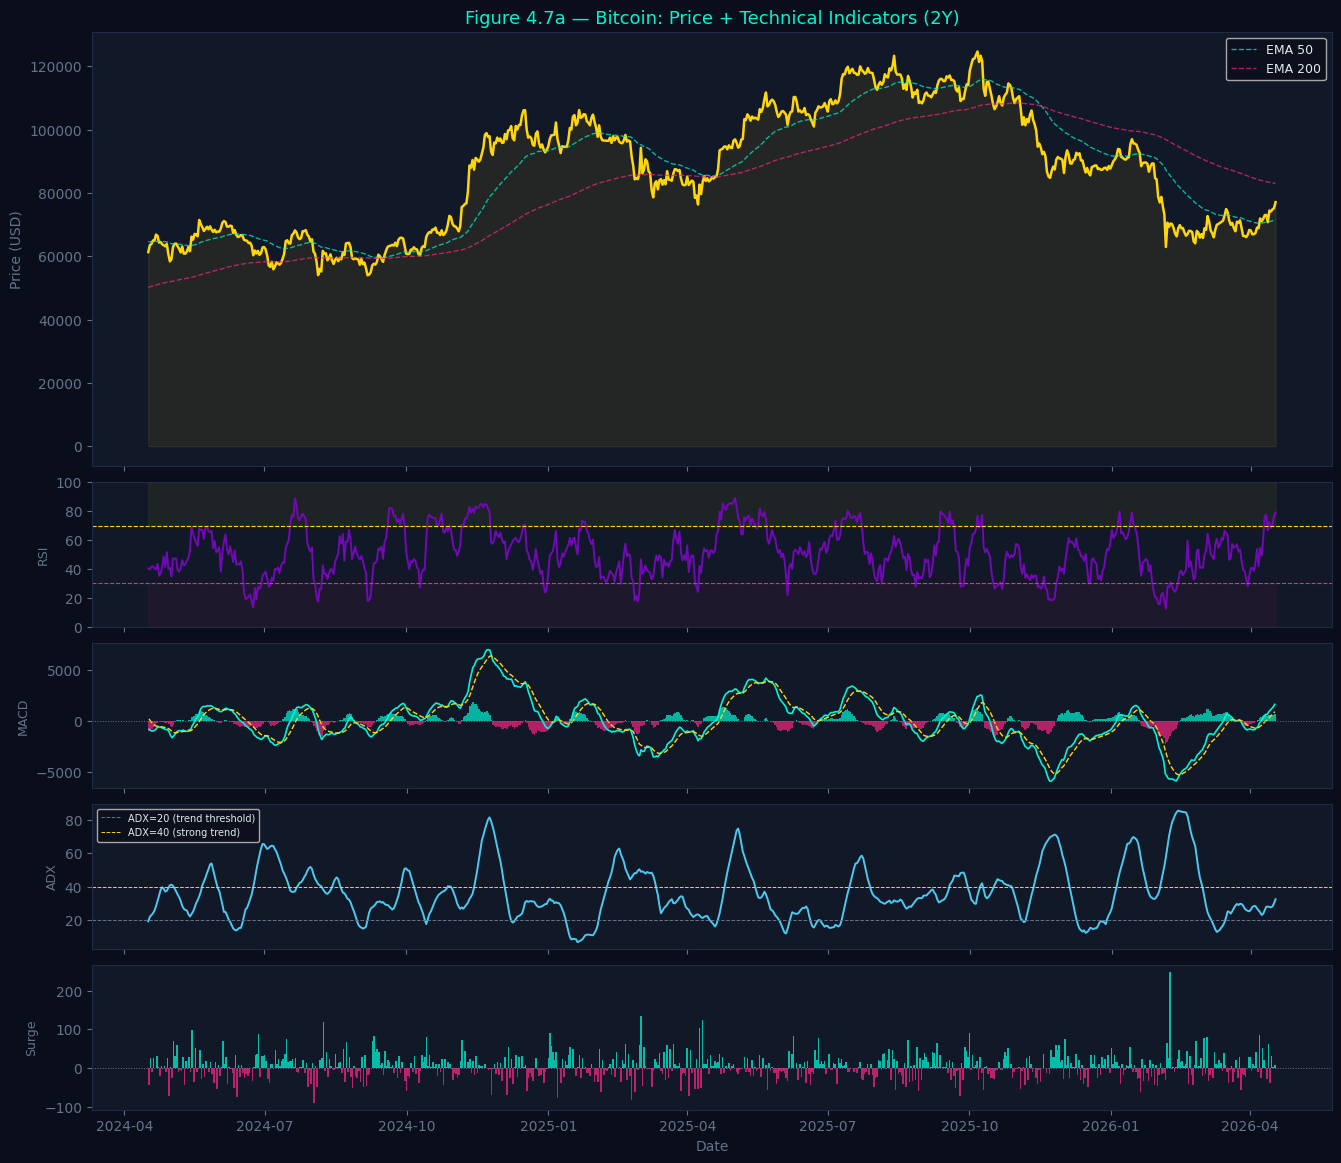

  ✓ Figure 4.7a saved.


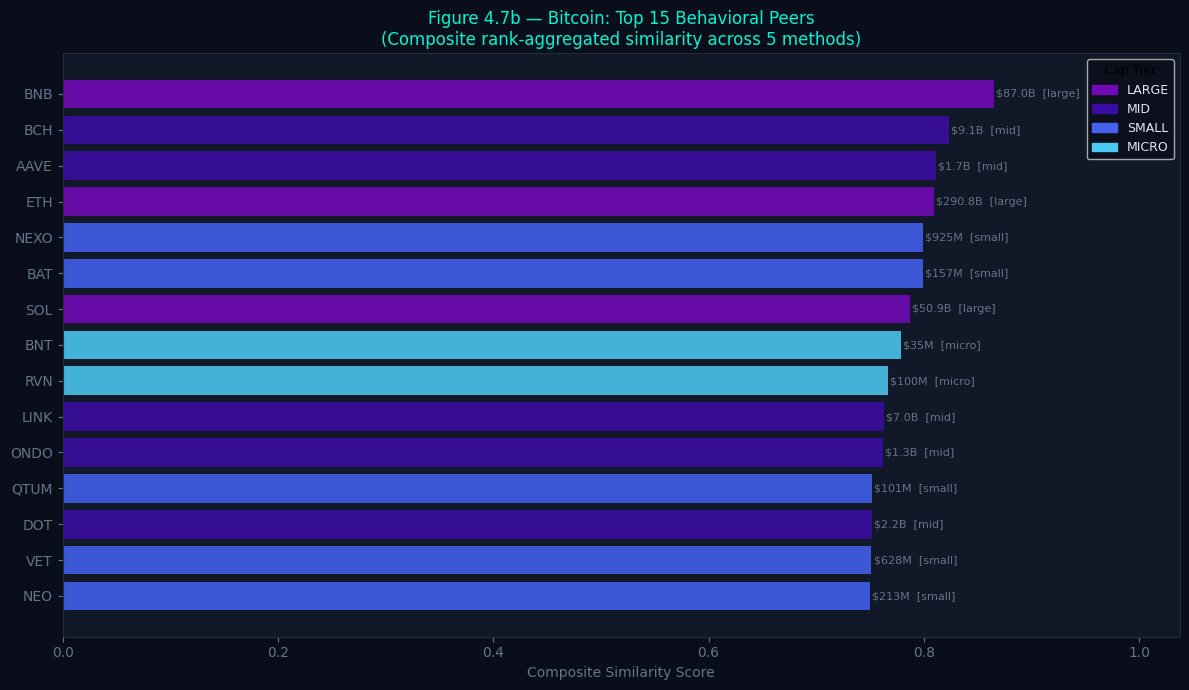

  ✓ Figure 4.7b saved.

  BTC top-15 composite peers:
symbol            name cap_tier  composite_sim
   BNB             BNB    large       0.864952
   BCH    Bitcoin Cash      mid       0.823292
  AAVE            Aave      mid       0.811207
   ETH        Ethereum    large       0.809239
  NEXO            NEXO    small       0.799228
   BAT Basic Attention    small       0.798879
   SOL          Solana    large       0.787287
   BNT  Bancor Network    micro       0.779089
   RVN       Ravencoin    micro       0.766976
  LINK       Chainlink      mid       0.763127
  ONDO            Ondo      mid       0.762073
  QTUM            Qtum    small       0.752048
   DOT        Polkadot      mid       0.751820
   VET         VeChain    small       0.751320
   NEO             NEO    small       0.750129


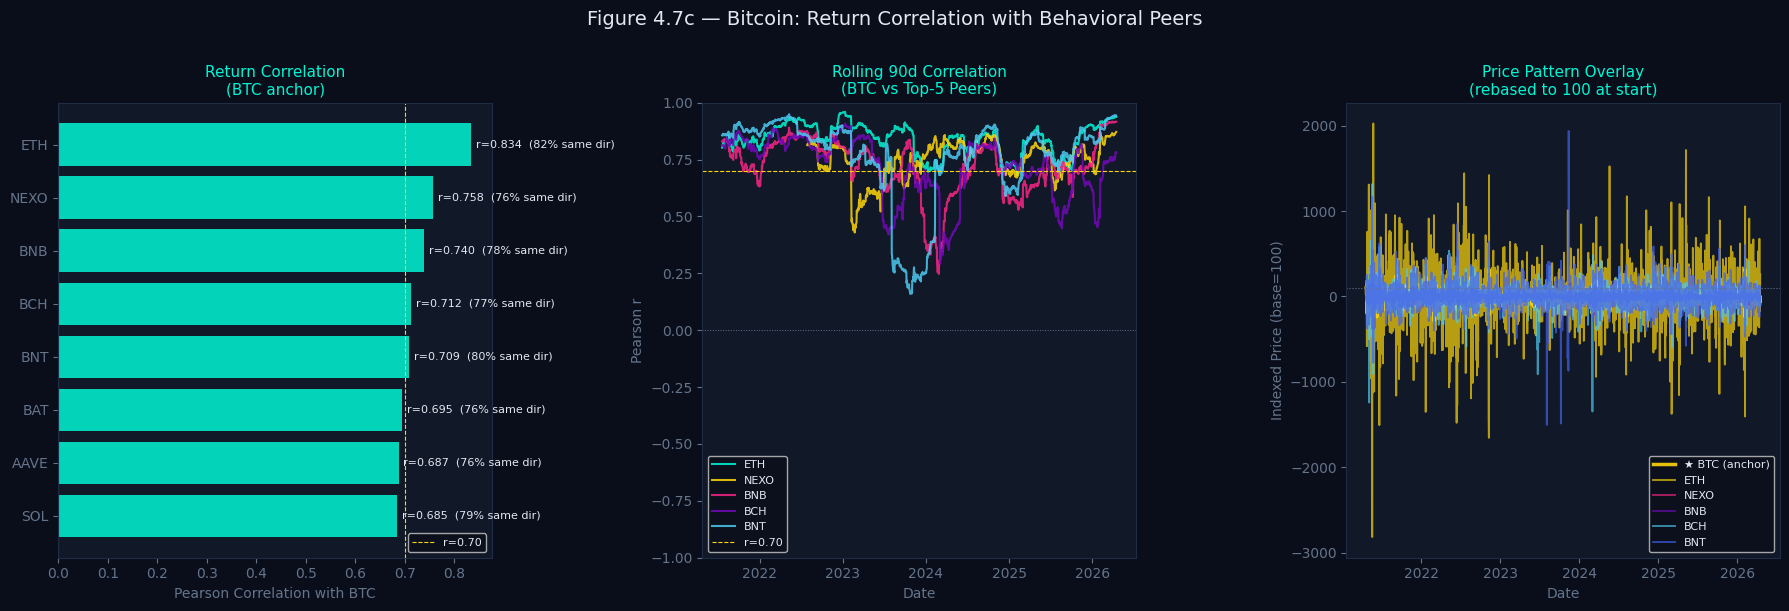

  ✓ Figure 4.7c saved.

  BTC peer correlation table:
symbol  pearson_r  pct_same_dir  n_obs       p_value
   ETH   0.834312     82.062534   1823  0.000000e+00
  NEXO   0.757995     75.776398   1449 8.097870e-271
   BNB   0.739703     78.496983   1823 1.378263e-315
   BCH   0.711833     76.906199   1823 9.816138e-282
   BNT   0.708648     79.539221   1823 4.018765e-278
   BAT   0.695393     76.467361   1823 1.334375e-263
  AAVE   0.687458     75.973670   1823 2.780726e-255
   SOL   0.684563     79.264948   1823 2.586650e-252


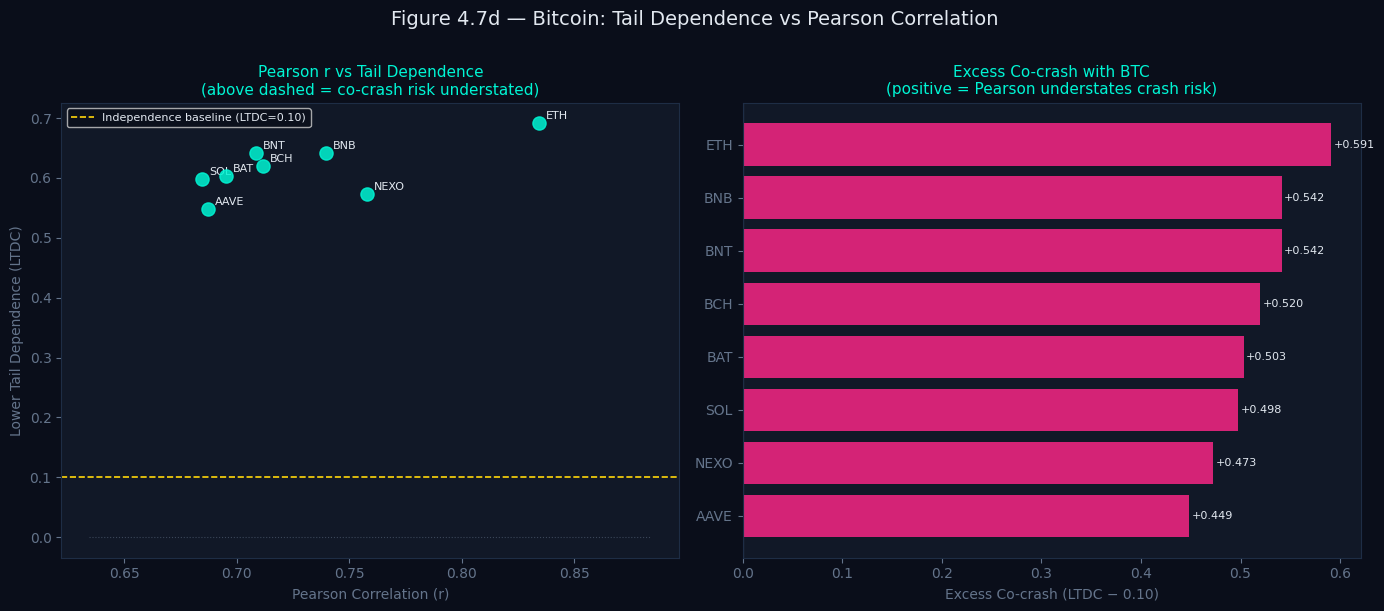

  ✓ Figure 4.7d saved.

  BTC tail dependence table:
symbol  pearson_r     ltdc     utdc  excess_crash
   ETH   0.834312 0.691168 0.570488      0.591168
   BNB   0.739703 0.641799 0.416895      0.541799
   BNT   0.708648 0.641799 0.532090      0.541799
   BCH   0.711833 0.619857 0.499177      0.519857
   BAT   0.695393 0.603401 0.438837      0.503401
   SOL   0.684563 0.597916 0.449808      0.497916
  NEXO   0.757995 0.572809 0.538302      0.472809
  AAVE   0.687458 0.548546 0.422381      0.448546


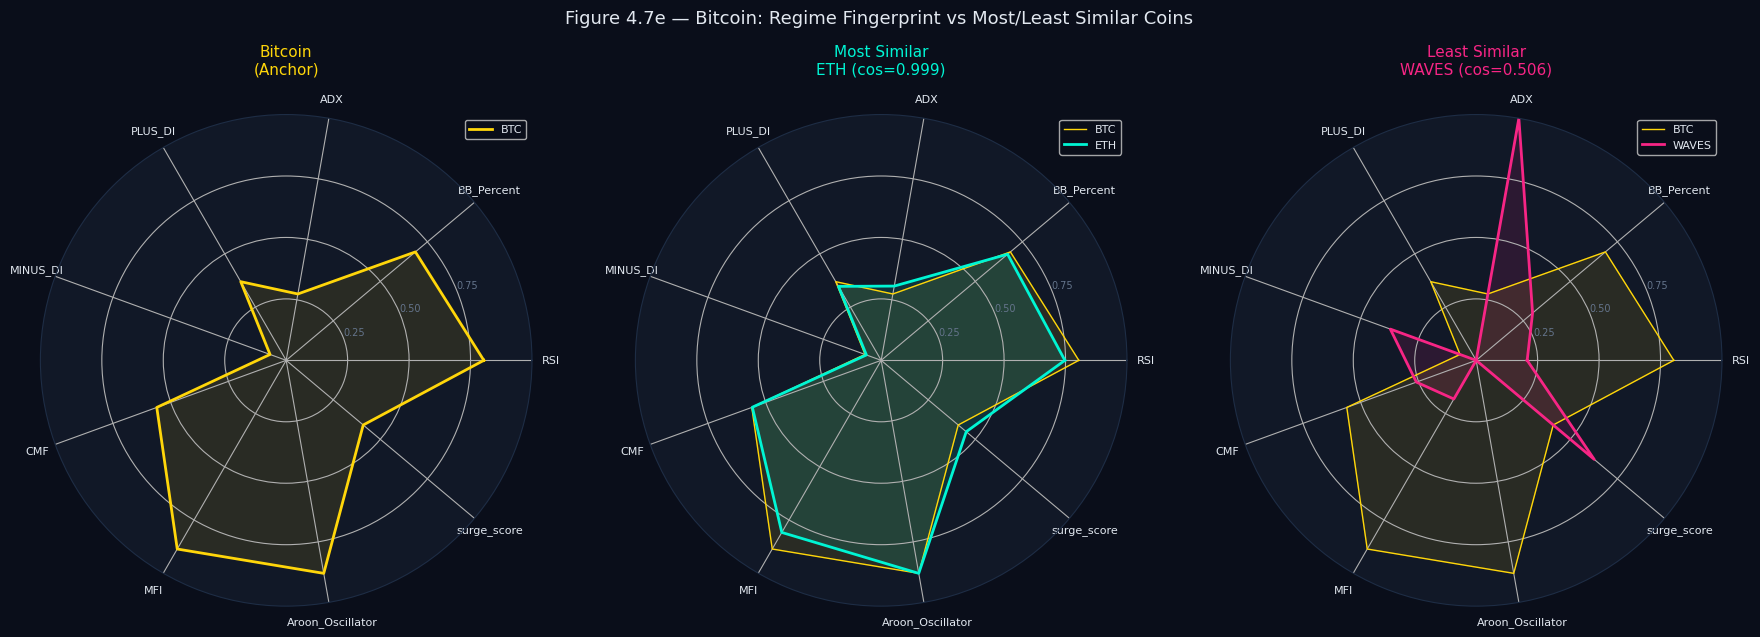

  ✓ Figure 4.7e saved.

  BTC most similar  : ETH  (cosine=0.9985)
  BTC least similar : WAVES  (cosine=0.5062)

  BTC current RSI=79.1, ADX=32.4, Surge=8.51
  Matched historical dates: 113
  Surge → 5d OLS: r=0.1550, p=0.1012, slope=5.6163


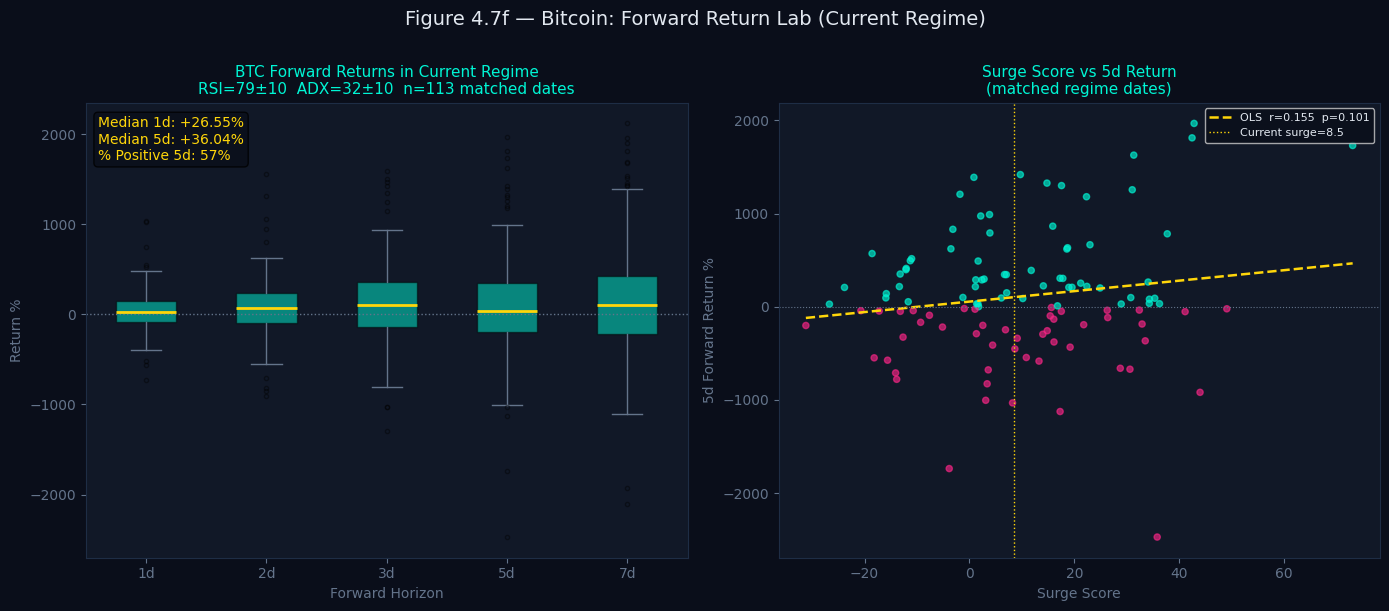

  ✓ Figure 4.7f saved.
  1d: median=+26.55%  pct_pos=59%  p25=-87.6%  p75=+142.4%
  2d: median=+74.68%  pct_pos=62%  p25=-101.0%  p75=+237.3%
  3d: median=+100.00%  pct_pos=62%  p25=-139.2%  p75=+360.4%
  5d: median=+36.04%  pct_pos=57%  p25=-201.1%  p75=+350.9%
  7d: median=+99.89%  pct_pos=57%  p25=-218.7%  p75=+426.8%

BITCOIN CASE STUDY COMPLETE
All figures saved to: similarity_outputs/bitcoin_case_study/


In [2]:
"""
═══════════════════════════════════════════════════════════════════════════════
BITCOIN CASE STUDY — Section 4.7
Thesis: Behavioral Similarity Classification of Cryptocurrency Assets

Shows how the full similarity framework applies to a single anchor coin (BTC)
and identifies its behavioral peers across all five methods.

INPUT  : crypto_with_indicators.parquet (or .csv)
         composite_similarity_matrix.csv
         cluster_assignments_K4.csv  (or whatever K your section_35 produced)

OUTPUT : All figures saved to similarity_outputs/bitcoin_case_study/

USAGE  : python bitcoin_case_study.py
═══════════════════════════════════════════════════════════════════════════════
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import os

OUTPUT_DIR   = "similarity_outputs/bitcoin_case_study"
SIM_DIR      = "similarity_outputs"
CONSENSUS_K  = 4          # match your section_35 output
BTC_ID       = "bitcoin"  # coin_id in your dataset
TOP_N        = 15         # peers to show
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

DARK = {
    "bg":     "#0a0e1a",
    "card":   "#111827",
    "border": "#1e2d45",
    "accent": "#00f5d4",
    "accent2":"#f72585",
    "gold":   "#ffd60a",
    "text":   "#e2e8f0",
    "muted":  "#64748b",
}

def dark_ax(ax):
    ax.set_facecolor(DARK["card"])
    ax.tick_params(colors=DARK["muted"])
    for spine in ax.spines.values():
        spine.set_edgecolor(DARK["border"])
    return ax


# ─────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────

def load_data():
    print("Loading data...")
    if os.path.exists("../data/crypto_with_indicators.parquet"):
        df = pl.scan_parquet("../data/crypto_with_indicators.parquet").collect().to_pandas()
    else:
        df = pd.read_csv("../data/crypto_with_indicators.csv", parse_dates=["date"])

    df["date"] = pd.to_datetime(df["date"])
    df = df[df["is_stablecoin"] == False].copy()
    df = df.sort_values(["coin_id", "date"])

    if "log_ret" not in df.columns:
        df["log_ret"] = df.groupby("coin_id")["close"].transform(
            lambda x: np.log(x / x.shift(1))
        )

    ret_pivot   = df.pivot_table(index="date", columns="coin_id", values="log_ret")
    close_pivot = df.pivot_table(index="date", columns="coin_id", values="close")

    # Summary
    summary = (
        df.groupby(["coin_id","symbol","name","cap_tier"])
        .agg(market_cap=("market_cap_usd","last"),
             volatility=("log_ret","std"))
        .reset_index()
    )

    # Composite similarity matrix
    sim_path = f"{SIM_DIR}/composite_similarity_matrix.csv"
    sim_df   = pd.read_csv(sim_path, index_col=0) if os.path.exists(sim_path) else None

    # Cluster assignments
    assign_path = f"{SIM_DIR}/cluster_assignments_K{CONSENSUS_K}.csv"
    assign_df   = pd.read_csv(assign_path) if os.path.exists(assign_path) else None

    print(f"  Coins: {df['coin_id'].nunique()}")
    print(f"  Date range: {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"  BTC found: {BTC_ID in df['coin_id'].values}")
    return df, ret_pivot, close_pivot, summary, sim_df, assign_df


# ─────────────────────────────────────────────────────────────
# FIGURE 1 — BTC PRICE + REGIME INDICATORS (5 panels)
# ─────────────────────────────────────────────────────────────

def figure_btc_price_regime(df: pd.DataFrame):
    """
    Five-panel chart: Price / RSI / MACD / ADX / Surge Score
    Shows BTC's own technical history as context for the similarity analysis.
    """
    btc = df[df["coin_id"] == BTC_ID].copy()
    btc["date"] = pd.to_datetime(btc["date"])

    if btc.empty:
        print(f"  BTC not found with coin_id='{BTC_ID}'. Check your coin_id.")
        return

    # Use last 2 years for readability
    cutoff = btc["date"].max() - pd.Timedelta(days=730)
    btc    = btc[btc["date"] >= cutoff]

    fig = plt.figure(figsize=(16, 14), facecolor=DARK["bg"])
    gs  = gridspec.GridSpec(5, 1, hspace=0.08,
                             height_ratios=[3, 1, 1, 1, 1])
    axes = [fig.add_subplot(gs[i]) for i in range(5)]
    for ax in axes:
        dark_ax(ax)

    # Panel 1: Price
    ax = axes[0]
    ax.plot(btc["date"], btc["close"], color=DARK["gold"], lw=1.8)
    ax.fill_between(btc["date"], btc["close"], alpha=0.08, color=DARK["gold"])
    if "EMA_50" in btc.columns:
        ax.plot(btc["date"], btc["EMA_50"],  color=DARK["accent"],  lw=1.0,
                ls="--", alpha=0.7, label="EMA 50")
    if "EMA_200" in btc.columns:
        ax.plot(btc["date"], btc["EMA_200"], color=DARK["accent2"], lw=1.0,
                ls="--", alpha=0.7, label="EMA 200")
    ax.set_ylabel("Price (USD)", color=DARK["muted"])
    ax.set_title("Figure 4.7a — Bitcoin: Price + Technical Indicators (2Y)",
                 color=DARK["accent"], fontsize=13)
    ax.legend(facecolor=DARK["bg"], labelcolor=DARK["text"], fontsize=9)
    ax.xaxis.set_ticklabels([])

    # Panel 2: RSI
    ax = axes[1]
    if "RSI" in btc.columns:
        ax.plot(btc["date"], btc["RSI"], color="#7209b7", lw=1.4)
        ax.axhline(70, color=DARK["gold"],   lw=0.8, ls="--")
        ax.axhline(30, color=DARK["accent2"], lw=0.8, ls="--")
        ax.fill_between(btc["date"], 70, 100, alpha=0.06, color=DARK["gold"])
        ax.fill_between(btc["date"],  0,  30, alpha=0.06, color=DARK["accent2"])
        ax.set_ylim(0, 100)
        ax.set_ylabel("RSI", color=DARK["muted"], fontsize=9)
    ax.xaxis.set_ticklabels([])

    # Panel 3: MACD
    ax = axes[2]
    if all(c in btc.columns for c in ["MACD", "MACD_Signal", "MACD_Hist"]):
        colors_hist = [DARK["accent"] if v >= 0 else DARK["accent2"]
                       for v in btc["MACD_Hist"].fillna(0)]
        ax.bar(btc["date"], btc["MACD_Hist"], color=colors_hist, alpha=0.7, width=1)
        ax.plot(btc["date"], btc["MACD"],        color=DARK["accent"], lw=1.2)
        ax.plot(btc["date"], btc["MACD_Signal"],  color=DARK["gold"],  lw=1.0, ls="--")
        ax.axhline(0, color=DARK["muted"], lw=0.7, ls=":")
        ax.set_ylabel("MACD", color=DARK["muted"], fontsize=9)
    ax.xaxis.set_ticklabels([])

    # Panel 4: ADX
    ax = axes[3]
    if "ADX" in btc.columns:
        ax.plot(btc["date"], btc["ADX"], color="#4cc9f0", lw=1.4)
        ax.axhline(20, color=DARK["muted"], lw=0.7, ls="--", label="ADX=20 (trend threshold)")
        ax.axhline(40, color=DARK["gold"],  lw=0.7, ls="--", label="ADX=40 (strong trend)")
        ax.set_ylabel("ADX", color=DARK["muted"], fontsize=9)
        ax.legend(facecolor=DARK["bg"], labelcolor=DARK["text"], fontsize=7)
    ax.xaxis.set_ticklabels([])

    # Panel 5: Surge Score
    ax = axes[4]
    if "surge_score" in btc.columns:
        surge = btc["surge_score"].fillna(0)
        colors_surge = [DARK["accent"] if v >= 0 else DARK["accent2"] for v in surge]
        ax.bar(btc["date"], surge, color=colors_surge, alpha=0.75, width=1)
        ax.axhline(0, color=DARK["muted"], lw=0.7, ls=":")
        ax.set_ylabel("Surge", color=DARK["muted"], fontsize=9)
    ax.set_xlabel("Date", color=DARK["muted"])

    # Remove x tick labels from all but last
    for ax in axes[:-1]:
        ax.set_xticklabels([])

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_47a_btc_price_regime.png",
                dpi=150, bbox_inches="tight", facecolor=DARK["bg"])
    plt.show()
    print("  ✓ Figure 4.7a saved.")


# ─────────────────────────────────────────────────────────────
# FIGURE 2 — BTC COMPOSITE SIMILARITY: TOP PEERS
# ─────────────────────────────────────────────────────────────

def figure_btc_composite_peers(sim_df: pd.DataFrame,
                                 summary: pd.DataFrame,
                                 top_n: int = TOP_N):
    """
    Horizontal bar chart of BTC's top-N most similar coins
    from the composite similarity matrix.
    Annotated with cap tier and market cap.
    """
    if sim_df is None or BTC_ID not in sim_df.columns:
        print(f"  Composite matrix not found or BTC not in it.")
        return pd.DataFrame()

    btc_row = sim_df[BTC_ID].drop(BTC_ID).sort_values(ascending=False).head(top_n)

    peers = btc_row.reset_index()
    peers.columns = ["coin_id", "composite_sim"]
    peers = peers.merge(
        summary[["coin_id","symbol","name","cap_tier","market_cap"]],
        on="coin_id", how="left"
    )

    fig, ax = plt.subplots(figsize=(12, 7), facecolor=DARK["bg"])
    dark_ax(ax)

    TIER_COLORS = {"mega":"#f72585","large":"#7209b7","mid":"#3a0ca3",
                   "small":"#4361ee","micro":"#4cc9f0"}
    bar_colors  = [TIER_COLORS.get(t, DARK["muted"])
                   for t in peers["cap_tier"].fillna("micro")]

    bars = ax.barh(
        peers["symbol"].fillna(peers["coin_id"]),
        peers["composite_sim"],
        color=bar_colors, alpha=0.88, edgecolor="none"
    )

    # Annotate with market cap
    for bar, row in zip(bars, peers.itertuples()):
        mc = row.market_cap if not pd.isna(row.market_cap) else 0
        mc_str = f"${mc/1e9:.1f}B" if mc >= 1e9 else f"${mc/1e6:.0f}M"
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f"{mc_str}  [{row.cap_tier}]" if not pd.isna(row.cap_tier)
                else mc_str,
                va="center", color=DARK["muted"], fontsize=8)

    ax.set_xlabel("Composite Similarity Score", color=DARK["muted"])
    ax.set_title(
        f"Figure 4.7b — Bitcoin: Top {top_n} Behavioral Peers\n"
        f"(Composite rank-aggregated similarity across 5 methods)",
        color=DARK["accent"], fontsize=12
    )
    ax.set_xlim(0, peers["composite_sim"].max() * 1.20)

    # Legend for tiers
    from matplotlib.patches import Patch
    legend_patches = [Patch(color=c, label=t.upper())
                      for t, c in TIER_COLORS.items()
                      if t in peers["cap_tier"].values]
    ax.legend(handles=legend_patches, facecolor=DARK["bg"],
              labelcolor=DARK["text"], fontsize=9, title="Cap Tier",
              title_fontsize=9)

    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_47b_btc_composite_peers.png",
                dpi=150, bbox_inches="tight", facecolor=DARK["bg"])
    plt.show()
    print("  ✓ Figure 4.7b saved.")
    print(f"\n  BTC top-{top_n} composite peers:")
    print(peers[["symbol","name","cap_tier","composite_sim"]].to_string(index=False))
    return peers


# ─────────────────────────────────────────────────────────────
# FIGURE 3 — BTC vs PEERS: RETURN CORRELATION
# ─────────────────────────────────────────────────────────────

def figure_btc_return_correlation(ret_pivot: pd.DataFrame,
                                   peers: pd.DataFrame,
                                   summary: pd.DataFrame,
                                   top_n: int = 8):
    """
    Three panels:
      1. Pearson r bar chart (BTC vs each peer)
      2. Rolling 90d correlation over time (top 5 peers)
      3. Normalised price overlay (rebased to 100)
    """
    if BTC_ID not in ret_pivot.columns:
        print("  BTC not in return pivot.")
        return

    peer_ids = peers["coin_id"].head(top_n).tolist() if not peers.empty else []
    sym_map  = summary.set_index("coin_id")["symbol"].to_dict()

    # Static Pearson r
    btc_ret = ret_pivot[BTC_ID].dropna()
    corr_rows = []
    for pid in peer_ids:
        if pid not in ret_pivot.columns:
            continue
        other = ret_pivot[pid].dropna()
        common = btc_ret.index.intersection(other.index)
        if len(common) < 60:
            continue
        r, p = stats.pearsonr(btc_ret.loc[common], other.loc[common])
        pct_dir = np.mean(np.sign(btc_ret.loc[common].values) ==
                          np.sign(other.loc[common].values)) * 100
        corr_rows.append({
            "coin_id":   pid,
            "symbol":    sym_map.get(pid, pid),
            "pearson_r": r,
            "p_value":   p,
            "pct_same_dir": pct_dir,
            "n_obs":     len(common),
        })
    corr_df = pd.DataFrame(corr_rows).sort_values("pearson_r", ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=DARK["bg"])
    for ax in axes:
        dark_ax(ax)

    # Panel 1: Pearson r bars
    ax = axes[0]
    bar_c = [DARK["accent"] if r >= 0 else DARK["accent2"]
             for r in corr_df["pearson_r"]]
    ax.barh(corr_df["symbol"], corr_df["pearson_r"],
            color=bar_c, alpha=0.85)
    ax.axvline(0, color=DARK["muted"], lw=0.8)
    ax.axvline(0.7, color=DARK["gold"], lw=0.8, ls="--", label="r=0.70")
    for i, row in enumerate(corr_df.itertuples()):
        ax.text(max(row.pearson_r, 0) + 0.01, i,
                f"r={row.pearson_r:.3f}  ({row.pct_same_dir:.0f}% same dir)",
                va="center", color=DARK["text"], fontsize=8)
    ax.set_xlabel("Pearson Correlation with BTC", color=DARK["muted"])
    ax.set_title("Return Correlation\n(BTC anchor)", color=DARK["accent"], fontsize=11)
    ax.legend(facecolor=DARK["bg"], labelcolor=DARK["text"], fontsize=8)
    ax.invert_yaxis()

    # Panel 2: Rolling 90d correlation
    ax      = axes[1]
    palette = [DARK["accent"], DARK["gold"], DARK["accent2"],
               "#7209b7","#4cc9f0","#4361ee","#f72585","#ffd60a"]
    top5    = corr_df.head(5)["coin_id"].tolist()

    for pid, color in zip(top5, palette):
        if pid not in ret_pivot.columns:
            continue
        combined = pd.DataFrame({
            "btc":   ret_pivot[BTC_ID],
            "other": ret_pivot[pid]
        }).dropna()
        if len(combined) < 100:
            continue
        rolling_r = combined["btc"].rolling(90).corr(combined["other"])
        ax.plot(rolling_r.index, rolling_r.values,
                color=color, lw=1.5, alpha=0.85,
                label=sym_map.get(pid, pid))

    ax.axhline(0.7, color=DARK["gold"], lw=0.8, ls="--", label="r=0.70")
    ax.axhline(0,   color=DARK["muted"], lw=0.7, ls=":")
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Date",      color=DARK["muted"])
    ax.set_ylabel("Pearson r", color=DARK["muted"])
    ax.set_title("Rolling 90d Correlation\n(BTC vs Top-5 Peers)",
                 color=DARK["accent"], fontsize=11)
    ax.legend(facecolor=DARK["bg"], labelcolor=DARK["text"], fontsize=8)

    # Panel 3: Normalised price overlay
    ax       = axes[2]
    all_ids  = [BTC_ID] + top5
    close_sub = ret_pivot[all_ids].fillna(0)
    # Rebase to 100 at start
    rebased   = close_sub.div(close_sub.bfill().iloc[0]) * 100

    for i, cid in enumerate(all_ids):
        if cid not in rebased.columns:
            continue
        is_btc = (cid == BTC_ID)
        color  = DARK["gold"] if is_btc else palette[i]
        lw     = 2.5 if is_btc else 1.3
        label  = f"★ BTC (anchor)" if is_btc else sym_map.get(cid, cid)
        ax.plot(rebased.index, rebased[cid],
                color=color, lw=lw, alpha=0.9 if is_btc else 0.7,
                label=label)

    ax.axhline(100, color=DARK["muted"], lw=0.8, ls=":")
    ax.set_xlabel("Date",                    color=DARK["muted"])
    ax.set_ylabel("Indexed Price (base=100)", color=DARK["muted"])
    ax.set_title("Price Pattern Overlay\n(rebased to 100 at start)",
                 color=DARK["accent"], fontsize=11)
    ax.legend(facecolor=DARK["bg"], labelcolor=DARK["text"], fontsize=8)

    plt.suptitle("Figure 4.7c — Bitcoin: Return Correlation with Behavioral Peers",
                 color=DARK["text"], fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_47c_btc_return_correlation.png",
                dpi=150, bbox_inches="tight", facecolor=DARK["bg"])
    plt.show()

    corr_df.to_csv(f"{OUTPUT_DIR}/table_btc_peer_correlations.csv", index=False)
    print("  ✓ Figure 4.7c saved.")
    print(f"\n  BTC peer correlation table:")
    print(corr_df[["symbol","pearson_r","pct_same_dir","n_obs","p_value"]].to_string(index=False))
    return corr_df


# ─────────────────────────────────────────────────────────────
# FIGURE 4 — BTC TAIL DEPENDENCE (Copula validation)
# ─────────────────────────────────────────────────────────────

def figure_btc_tail_dependence(ret_pivot: pd.DataFrame,
                                 corr_df: pd.DataFrame,
                                 summary: pd.DataFrame):
    """
    For BTC vs its top 3 return-correlated peers:
    Compare Pearson r against empirical lower tail dependence (LTDC).
    Key thesis point: LTDC > Pearson means co-crash risk is understated
    by standard correlation.
    """
    if corr_df.empty or BTC_ID not in ret_pivot.columns:
        return

    sym_map = summary.set_index("coin_id")["symbol"].to_dict()
    btc_ret = ret_pivot[BTC_ID].dropna()

    def empirical_ltdc(u, v, q=0.10):
        n = len(u)
        return np.sum((u <= q) & (v <= q)) / (n * q)

    rows = []
    for pid in corr_df.head(8)["coin_id"].tolist():
        if pid not in ret_pivot.columns:
            continue
        other  = ret_pivot[pid].dropna()
        common = btc_ret.index.intersection(other.index)
        if len(common) < 100:
            continue
        btc_v  = btc_ret.loc[common].values
        oth_v  = other.loc[common].values
        pearson_r, _ = stats.pearsonr(btc_v, oth_v)

        from scipy.stats import rankdata
        ui = rankdata(btc_v) / (len(btc_v) + 1)
        uj = rankdata(oth_v) / (len(oth_v) + 1)
        ltdc = empirical_ltdc(ui, uj, q=0.10)
        utdc = np.sum((ui > 0.90) & (uj > 0.90)) / (len(ui) * 0.10)

        rows.append({
            "coin_id":   pid,
            "symbol":    sym_map.get(pid, pid),
            "pearson_r": pearson_r,
            "ltdc":      ltdc,
            "utdc":      utdc,
            "excess_crash": ltdc - 0.10,  # vs independence baseline of q=0.10
        })

    td_df = pd.DataFrame(rows).sort_values("ltdc", ascending=False)
    td_df.to_csv(f"{OUTPUT_DIR}/table_btc_tail_dependence.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=DARK["bg"])
    for ax in axes:
        dark_ax(ax)

    # Panel 1: Pearson r vs LTDC scatter
    ax = axes[0]
    ax.scatter(td_df["pearson_r"], td_df["ltdc"],
               s=90, color=DARK["accent"], alpha=0.85, zorder=5)
    for _, row in td_df.iterrows():
        ax.annotate(row["symbol"],
                    (row["pearson_r"], row["ltdc"]),
                    xytext=(5, 3), textcoords="offset points",
                    color=DARK["text"], fontsize=8)

    # Independence line: LTDC = q = 0.10 (flat)
    lims = [td_df["pearson_r"].min() - 0.05, td_df["pearson_r"].max() + 0.05]
    ax.axhline(0.10, color=DARK["gold"], lw=1.2, ls="--",
               label="Independence baseline (LTDC=0.10)")
    ax.plot(lims, lims * np.ones(2) * 0, color=DARK["muted"],
            lw=0.8, ls=":", alpha=0.5)
    ax.set_xlabel("Pearson Correlation (r)", color=DARK["muted"])
    ax.set_ylabel("Lower Tail Dependence (LTDC)", color=DARK["muted"])
    ax.set_title("Pearson r vs Tail Dependence\n(above dashed = co-crash risk understated)",
                 color=DARK["accent"], fontsize=11)
    ax.legend(facecolor=DARK["bg"], labelcolor=DARK["text"], fontsize=8)

    # Panel 2: Excess co-crash bar chart
    ax = axes[1]
    colors_bar = [DARK["accent2"] if v > 0 else DARK["muted"]
                  for v in td_df["excess_crash"]]
    ax.barh(td_df["symbol"], td_df["excess_crash"],
            color=colors_bar, alpha=0.85)
    ax.axvline(0, color=DARK["muted"], lw=0.8)
    ax.set_xlabel("Excess Co-crash (LTDC − 0.10)", color=DARK["muted"])
    ax.set_title("Excess Co-crash with BTC\n(positive = Pearson understates crash risk)",
                 color=DARK["accent"], fontsize=11)
    for i, row in enumerate(td_df.itertuples()):
        ax.text(max(row.excess_crash, 0) + 0.002, i,
                f"+{row.excess_crash:.3f}" if row.excess_crash >= 0
                else f"{row.excess_crash:.3f}",
                va="center", color=DARK["text"], fontsize=8)
    ax.invert_yaxis()

    plt.suptitle("Figure 4.7d — Bitcoin: Tail Dependence vs Pearson Correlation",
                 color=DARK["text"], fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_47d_btc_tail_dependence.png",
                dpi=150, bbox_inches="tight", facecolor=DARK["bg"])
    plt.show()
    print("  ✓ Figure 4.7d saved.")
    print(f"\n  BTC tail dependence table:")
    print(td_df[["symbol","pearson_r","ltdc","utdc","excess_crash"]].to_string(index=False))
    return td_df


# ─────────────────────────────────────────────────────────────
# FIGURE 5 — BTC REGIME SIMILARITY RADAR
# ─────────────────────────────────────────────────────────────

def figure_btc_regime_radar(df: pd.DataFrame,
                              sim_df: pd.DataFrame,
                              summary: pd.DataFrame):
    """
    Radar chart: BTC's current regime vector vs its top regime-similar peer
    and a deliberately dissimilar coin.
    Shows the 11-feature technical fingerprint visually.
    """
    REGIME_FEATURES = ["RSI","BB_Percent","ADX","PLUS_DI","MINUS_DI",
                        "CMF","MFI","Aroon_Oscillator","surge_score"]
    avail = [f for f in REGIME_FEATURES if f in df.columns]

    # Latest snapshot per coin
    snap = (
        df.sort_values("date")
        .groupby("coin_id")[avail]
        .last()
        .reset_index()
    )
    snap = snap.merge(
        summary[["coin_id","symbol","cap_tier"]],
        on="coin_id", how="left"
    ).dropna(subset=avail)

    if BTC_ID not in snap["coin_id"].values:
        print("  BTC not in regime snapshot.")
        return

    # Normalise 0-1
    feat_vals = snap[avail].astype(float)
    normed = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-10)
    snap[avail] = normed

    btc_vec = snap[snap["coin_id"] == BTC_ID][avail].values[0]

    # Find most similar and least similar coins (excluding BTC)
    others = snap[snap["coin_id"] != BTC_ID].copy()
    from sklearn.metrics.pairwise import cosine_similarity
    cos_vals = cosine_similarity(
        btc_vec.reshape(1, -1),
        others[avail].values
    ).flatten()
    others["cosine_sim"] = cos_vals

    most_sim  = others.nlargest(1, "cosine_sim").iloc[0]
    least_sim = others.nsmallest(1, "cosine_sim").iloc[0]

    # Radar
    labels    = avail
    n_labels  = len(labels)
    angles    = np.linspace(0, 2 * np.pi, n_labels, endpoint=False).tolist()
    angles   += angles[:1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw=dict(polar=True),
                              facecolor=DARK["bg"])

    def radar_values(row_id):
        if row_id == BTC_ID:
            v = btc_vec.tolist()
        else:
            v = others[others["coin_id"] == row_id][avail].values[0].tolist()
        return v + v[:1]

    configs = [
        (BTC_ID,            "★ BTC",         DARK["gold"],   f"Bitcoin\n(Anchor)"),
        (most_sim["coin_id"], most_sim["symbol"],  DARK["accent"],
         f"Most Similar\n{most_sim['symbol']} (cos={most_sim['cosine_sim']:.3f})"),
        (least_sim["coin_id"], least_sim["symbol"], DARK["accent2"],
         f"Least Similar\n{least_sim['symbol']} (cos={least_sim['cosine_sim']:.3f})"),
    ]

    for ax_idx, (cid, sym, color, title) in enumerate(configs):
        ax = axes[ax_idx]
        ax.set_facecolor(DARK["card"])
        ax.spines["polar"].set_color(DARK["border"])
        ax.tick_params(colors=DARK["muted"])

        # BTC reference on all panels
        btc_v = btc_vec.tolist() + btc_vec[:1].tolist()
        ax.plot(angles, btc_v, color=DARK["gold"],
                lw=2.0 if cid == BTC_ID else 1.0,
                ls="-", label="BTC")
        ax.fill(angles, btc_v, alpha=0.10, color=DARK["gold"])

        if cid != BTC_ID:
            peer_v = radar_values(cid)
            ax.plot(angles, peer_v, color=color, lw=2.0, label=sym)
            ax.fill(angles, peer_v, alpha=0.12, color=color)

        ax.set_thetagrids(np.degrees(angles[:-1]), labels,
                          color=DARK["text"], fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75])
        ax.set_yticklabels(["0.25","0.50","0.75"],
                            color=DARK["muted"], fontsize=7)
        ax.set_title(title, color=color, fontsize=11, pad=15)
        ax.legend(facecolor=DARK["bg"], labelcolor=DARK["text"],
                  fontsize=8, loc="upper right")

    fig.suptitle(
        "Figure 4.7e — Bitcoin: Regime Fingerprint vs Most/Least Similar Coins",
        color=DARK["text"], fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_47e_btc_regime_radar.png",
                dpi=150, bbox_inches="tight", facecolor=DARK["bg"])
    plt.show()
    print("  ✓ Figure 4.7e saved.")
    print(f"\n  BTC most similar  : {most_sim['symbol']}  (cosine={most_sim['cosine_sim']:.4f})")
    print(f"  BTC least similar : {least_sim['symbol']}  (cosine={least_sim['cosine_sim']:.4f})")
    return most_sim, least_sim


# ─────────────────────────────────────────────────────────────
# FIGURE 6 — BTC FORWARD RETURN LAB
# ─────────────────────────────────────────────────────────────

def figure_btc_forward_returns(df: pd.DataFrame):
    """
    Box plots of BTC forward returns (1d/2d/3d/5d/7d) in the current
    RSI+ADX regime, with surge score scatter for 5d horizon.
    """
    btc = df[df["coin_id"] == BTC_ID].copy()
    if btc.empty:
        return

    fwd_cols = [c for c in btc.columns if c.startswith("Next_") and "Return" in c]
    if not fwd_cols or "RSI" not in btc.columns or "ADX" not in btc.columns:
        print("  Forward return columns not available.")
        return

    # Current regime
    latest       = btc.sort_values("date").iloc[-1]
    anchor_rsi   = latest["RSI"]
    anchor_adx   = latest["ADX"]
    anchor_surge = latest.get("surge_score", np.nan)

    rsi_tol = 10
    adx_tol = 10

    matched = btc[
        btc["RSI"].between(anchor_rsi - rsi_tol, anchor_rsi + rsi_tol) &
        btc["ADX"].between(anchor_adx - adx_tol, anchor_adx + adx_tol)
    ].dropna(subset=["Next_1d_Return","Next_5d_Return"])

    print(f"\n  BTC current RSI={anchor_rsi:.1f}, ADX={anchor_adx:.1f}, "
          f"Surge={anchor_surge:.2f}")
    print(f"  Matched historical dates: {len(matched)}")

    if len(matched) < 10:
        print("  Too few matches — widen tolerance.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=DARK["bg"])
    for ax in axes:
        dark_ax(ax)

    # Panel 1: Box plots
    ax      = axes[0]
    ret_labels = ["1d","2d","3d","5d","7d"]
    ret_cols   = ["Next_1d_Return","Next_2d_Return","Next_3d_Return",
                  "Next_5d_Return","Next_7d_Return"]
    ret_cols   = [c for c in ret_cols if c in matched.columns]

    data_for_box = [(matched[c].dropna() * 100).values for c in ret_cols]
    bp = ax.boxplot(
        data_for_box,
        labels     = ret_labels[:len(data_for_box)],
        patch_artist= True,
        medianprops = dict(color=DARK["gold"], lw=2),
        whiskerprops= dict(color=DARK["muted"]),
        capprops    = dict(color=DARK["muted"]),
        flierprops  = dict(marker="o", color=DARK["accent2"],
                           alpha=0.4, markersize=3),
    )
    for patch, vals in zip(bp["boxes"], data_for_box):
        color = DARK["accent"] if np.median(vals) >= 0 else DARK["accent2"]
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    ax.axhline(0, color=DARK["muted"], lw=1, ls=":")
    ax.set_xlabel("Forward Horizon", color=DARK["muted"])
    ax.set_ylabel("Return %",        color=DARK["muted"])
    ax.set_title(
        f"BTC Forward Returns in Current Regime\n"
        f"RSI={anchor_rsi:.0f}±{rsi_tol}  ADX={anchor_adx:.0f}±{adx_tol}  "
        f"n={len(matched)} matched dates",
        color=DARK["accent"], fontsize=11
    )

    # Key stats text box
    med_1d = np.median(data_for_box[0]) if data_for_box else np.nan
    med_5d = np.median(data_for_box[3]) if len(data_for_box) > 3 else np.nan
    pct_pos_5d = (matched["Next_5d_Return"] > 0).mean() * 100 \
                  if "Next_5d_Return" in matched.columns else np.nan
    ax.text(0.02, 0.97,
            f"Median 1d: {med_1d:+.2f}%\n"
            f"Median 5d: {med_5d:+.2f}%\n"
            f"% Positive 5d: {pct_pos_5d:.0f}%",
            transform=ax.transAxes, color=DARK["gold"], fontsize=10,
            va="top",
            bbox=dict(boxstyle="round", facecolor=DARK["bg"], alpha=0.8))

    # Panel 2: Surge score vs 5d return scatter
    ax = axes[1]
    if "surge_score" in matched.columns and "Next_5d_Return" in matched.columns:
        sc = matched[["surge_score","Next_5d_Return","date"]].dropna()
        sc["ret_5d_pct"] = sc["Next_5d_Return"] * 100
        dot_colors = [DARK["accent"] if v >= 0 else DARK["accent2"]
                      for v in sc["ret_5d_pct"]]
        ax.scatter(sc["surge_score"], sc["ret_5d_pct"],
                   s=20, color=dot_colors, alpha=0.65)

        if len(sc) >= 10:
            slope, intercept, r_val, p_val, _ = stats.linregress(
                sc["surge_score"], sc["ret_5d_pct"]
            )
            x_line = np.linspace(sc["surge_score"].min(),
                                  sc["surge_score"].max(), 50)
            ax.plot(x_line, slope * x_line + intercept,
                    color=DARK["gold"], lw=1.8, ls="--",
                    label=f"OLS  r={r_val:.3f}  p={p_val:.3f}")
            print(f"  Surge → 5d OLS: r={r_val:.4f}, p={p_val:.4f}, "
                  f"slope={slope:.4f}")

        ax.axhline(0, color=DARK["muted"], lw=0.8, ls=":")
        ax.axvline(anchor_surge, color=DARK["gold"], lw=1.0, ls=":",
                   label=f"Current surge={anchor_surge:.1f}" if not pd.isna(anchor_surge) else "")
        ax.set_xlabel("Surge Score",       color=DARK["muted"])
        ax.set_ylabel("5d Forward Return %", color=DARK["muted"])
        ax.set_title("Surge Score vs 5d Return\n(matched regime dates)",
                     color=DARK["accent"], fontsize=11)
        ax.legend(facecolor=DARK["bg"], labelcolor=DARK["text"], fontsize=8)

    plt.suptitle("Figure 4.7f — Bitcoin: Forward Return Lab (Current Regime)",
                 color=DARK["text"], fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_47f_btc_forward_returns.png",
                dpi=150, bbox_inches="tight", facecolor=DARK["bg"])
    plt.show()
    print("  ✓ Figure 4.7f saved.")

    # Print summary stats for the write-up
    for lbl, col in zip(ret_labels, ret_cols):
        vals = matched[col].dropna() * 100
        print(f"  {lbl}: median={vals.median():+.2f}%  "
              f"pct_pos={( vals>0).mean()*100:.0f}%  "
              f"p25={vals.quantile(0.25):+.1f}%  "
              f"p75={vals.quantile(0.75):+.1f}%")


# ─────────────────────────────────────────────────────────────
# MAIN RUNNER
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    df, ret_pivot, close_pivot, summary, sim_df, assign_df = load_data()

    print("\n" + "="*60)
    print("BITCOIN CASE STUDY — generating all figures")
    print("="*60)

    # Figure 4.7a — BTC price + regime indicators
    figure_btc_price_regime(df)

    # Figure 4.7b — composite similarity peers
    peers = figure_btc_composite_peers(sim_df, summary, top_n=TOP_N)

    # Figure 4.7c — return correlation
    corr_df = figure_btc_return_correlation(ret_pivot, peers, summary, top_n=8)

    # Figure 4.7d — tail dependence
    td_df = figure_btc_tail_dependence(ret_pivot, corr_df, summary)

    # Figure 4.7e — regime radar
    most_sim, least_sim = figure_btc_regime_radar(df, sim_df, summary)

    # Figure 4.7f — forward return lab
    figure_btc_forward_returns(df)

    print("\n" + "="*60)
    print(f"BITCOIN CASE STUDY COMPLETE")
    print(f"All figures saved to: {OUTPUT_DIR}/")
    print("="*60)